# Modelagem de Churn com Rede Neural

Este notebook treina uma rede neural para prever a probabilidade de churn dos clientes da Telco. A sequência é: importar ferramentas, carregar a base limpa, separar treino e teste, aplicar o pré-processamento, treinar o modelo, avaliar métricas e testar um threshold alternativo.


## 1. Importação das bibliotecas principais

Neste bloco vamos importar as bibliotecas usadas no treino e na avaliação. `numpy` apoia operações numéricas, `matplotlib` gera gráficos, `scikit-learn` fornece divisão treino/teste, pesos de classe e métricas, e `TensorFlow/Keras` constrói a rede neural.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models

## 2. Acesso às funções do projeto

Como o notebook está dentro da pasta `notebooks`, adicionamos `..` ao caminho de busca do Python para importar arquivos da pasta `src`. Em seguida, trazemos a função de limpeza, o construtor do pré-processador e as listas de colunas definidas em `preprocess.py`.


In [2]:
import sys
sys.path.append("..")
from src.preprocess import load_clean, build_preprocessor, NUMERIC, CATEGORICAL, BINARY_INT

## 3. Carregamento da base limpa

Aqui vamos carregar o CSV original usando `load_clean`. Essa função já trata `TotalCharges` e transforma `Churn` em alvo numérico, onde `0` representa cliente que não cancelou e `1` representa cliente que cancelou. O `head()` mostra uma amostra para conferirmos se a leitura funcionou.


In [3]:
df = load_clean("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


A amostra mostra que a base foi carregada com as colunas esperadas e que `Churn` já aparece como `0` e `1`. Também dá para ver que `TotalCharges` está numérico, por exemplo `29.85`, `1889.50` e `108.15`. Isso confirma que a base já está em um formato mais adequado para modelagem.


## 4. Verificação do desbalanceamento do alvo

Neste bloco vamos calcular a proporção das classes em `Churn`. Essa checagem é importante porque problemas de churn costumam ter menos clientes cancelando do que permanecendo, e isso muda como devemos treinar e avaliar o modelo.


In [4]:
df["Churn"].value_counts(normalize=True)

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

O resultado mostra cerca de **73,46%** de clientes na classe `0` e **26,54%** na classe `1`. Portanto, a base é desbalanceada. Isso explica por que depois usamos `class_weight` e por que métricas como recall, precision, AUC e matriz de confusão são mais informativas do que olhar apenas a precisão.


## 5. Separação de features, alvo e identificadores

Aqui vamos montar `X`, `y` e `ids`. `X` recebe apenas as colunas que podem ser usadas como entrada do modelo. `y` recebe o alvo `Churn`. `ids` guarda `customerID` separado para rastrear clientes depois, sem usar esse identificador como variável preditiva.


In [5]:
FEATURES = NUMERIC + CATEGORICAL + BINARY_INT

X = df[FEATURES]
y = df["Churn"].values
ids = df["customerID"].values

## 6. Divisão entre treino e teste

Neste bloco vamos dividir os dados em treino e teste. O conjunto de treino ensina o modelo; o conjunto de teste avalia o desempenho em dados não vistos. O parâmetro `stratify=y` mantém a proporção de churn parecida nos dois conjuntos.


In [6]:
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(X, y, ids, test_size=0.2, stratify=y,random_state=42)

## 7. Ajuste do pré-processador

Agora vamos criar o pré-processador e aplicá-lo aos dados. No treino usamos `fit_transform`, porque o pré-processador precisa aprender médias, desvios e categorias. No teste usamos apenas `transform`, para aplicar as regras aprendidas no treino sem deixar o teste influenciar o processo.


In [7]:
pre = build_preprocessor()

X_train_mat = pre.fit_transform(X_train)
X_test_mat = pre.transform(X_test)

A célula não imprime saída, mas transforma os dados brutos em matrizes numéricas. Esse é um passo obrigatório para a rede neural, porque ela não entende categorias em texto como `Month-to-month` ou `Fiber optic`. O cuidado principal foi ajustar o pré-processador apenas no treino, evitando vazamento de dados.


## 8. Conversão opcional para array denso

Alguns transformadores do `scikit-learn` podem devolver uma matriz esparsa, que economiza memória quando existem muitos zeros. Este bloco verifica se existe o método `toarray()` e, se existir, converte a matriz para um array comum, mais fácil de passar para o Keras.


In [8]:
if hasattr(X_train_mat, "toarray"):
    X_train_mat = X_train_mat.toarray()
    X_test_mat = X_test_mat.toarray()

## 9. Quantidade de entradas da rede

Depois do one-hot encoding, o número de colunas aumenta. Aqui vamos medir quantas features finais existem na matriz processada, porque a camada de entrada da rede neural precisa saber exatamente esse tamanho.


In [9]:
n_features = X_train_mat.shape[1]
n_features

45

O resultado foi **45 features** depois do pré-processamento. Isso significa que as colunas originais viraram uma matriz com 45 entradas por cliente, principalmente por causa das variáveis categóricas transformadas em várias colunas binárias pelo one-hot encoding.


## 10. Definição da arquitetura da rede neural

Neste bloco vamos criar uma MLP simples para classificação binária. Ela recebe as 45 features processadas, passa por duas camadas densas com `ReLU`, usa `Dropout` para reduzir overfitting e termina com uma camada `sigmoid`, que gera uma probabilidade de churn entre 0 e 1.


In [10]:
model = models.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid"),
])

A célula cria o objeto `model`, mas ainda não treina nada. A arquitetura é adequada como ponto de partida para uma base tabular pequena: não é grande demais, tem alguma capacidade de aprender relações não lineares e usa dropout para tentar melhorar generalização.


## 11. Compilação do modelo

Aqui vamos definir como o modelo vai aprender. A função de perda `binary_crossentropy` é adequada para classificação binária. O otimizador `Adam` ajusta os pesos da rede. As métricas acompanham acurácia, AUC, precision e recall durante o treino.


In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

A célula não exibe saída, mas deixa o modelo pronto para treinar. A escolha das métricas é importante: em churn, acurácia sozinha pode enganar, porque a classe `0` é maioria. AUC, precision e recall ajudam a entender melhor se o modelo encontra clientes que realmente cancelam.


## 12. Cálculo dos pesos de classe

Como a classe churn (`1`) aparece menos, vamos calcular pesos para equilibrar a importância das classes durante o treino. A ideia é penalizar mais os erros na classe minoritária, ajudando o modelo a prestar mais atenção nos clientes que cancelaram.


In [12]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0,1]),
    y=y_train
)

class_weight = {
    0: weights[0],
    1: weights[1],
}

class_weight

{0: np.float64(0.6805991785455424), 1: np.float64(1.8842809364548494)}

O peso da classe `0` ficou em aproximadamente **0,68**, enquanto o peso da classe `1` ficou em aproximadamente **1,88**. Isso confirma que o treino dará mais importância aos exemplos de churn. Essa escolha combina com o objetivo do projeto, já que detectar clientes em risco costuma ser mais valioso do que maximizar apenas a acurácia geral.


## 13. Configuração do EarlyStopping

Neste bloco vamos configurar uma parada antecipada. O callback acompanha `val_auc` e interrompe o treino quando a métrica de validação para de melhorar por várias épocas. Com `restore_best_weights=True`, o modelo volta para os melhores pesos encontrados.


In [13]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=10,
    restore_best_weights=True

)

## 14. Treinamento da rede neural

Agora vamos treinar o modelo. O treino usa as matrizes processadas, separa uma parte do treino para validação, aplica os pesos de classe e permite até 100 épocas. O `EarlyStopping` pode interromper antes se a AUC de validação estabilizar.


In [14]:
history = model.fit(
    X_train_mat,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6934 - auc: 0.7721 - loss: 0.5753 - precision: 0.4527 - recall: 0.7258 - val_accuracy: 0.7240 - val_auc: 0.8153 - val_loss: 0.5254 - val_precision: 0.4831 - val_recall: 0.7729
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7382 - auc: 0.8164 - loss: 0.5243 - precision: 0.5056 - recall: 0.7500 - val_accuracy: 0.7303 - val_auc: 0.8221 - val_loss: 0.5237 - val_precision: 0.4906 - val_recall: 0.7966
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7428 - auc: 0.8295 - loss: 0.5061 - precision: 0.5110 - recall: 0.7908 - val_accuracy: 0.7285 - val_auc: 0.8247 - val_loss: 0.5085 - val_precision: 0.4882 - val_recall: 0.7695
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7562 - auc: 0.8412 - loss: 0.4936 - precision: 0.5280 - recall: 0.7925 - val_accuracy: 0.7329 - val_auc: 0.8246 - val_loss: 0.5035 - val_precision: 0.4934 - val_recall: 0.7627
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━

O log mostra que a AUC de treino começou perto de **0,74** e subiu ao longo das épocas, enquanto a AUC de validação saiu de cerca de **0,81** e estabilizou por volta de **0,82-0,83**. Isso sugere que o modelo aprendeu padrões úteis, mas também que há um limite claro de melhoria na validação. Se o treino continuar subindo e a validação ficar parada, temos sinal de leve overfitting.


## 15. Geração das probabilidades e classes previstas

Depois do treino, vamos usar o conjunto de teste para gerar probabilidades de churn. `proba` guarda valores entre 0 e 1. Em seguida, usamos o threshold padrão de `0.5`: probabilidades maiores ou iguais a 0.5 viram classe `1`, e as demais viram classe `0`.


In [15]:
proba = model.predict(X_test_mat).ravel()
pred = (proba >= 0.5).astype(int)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


A saída mostra que o modelo gerou previsões para o conjunto de teste. A diferença conceitual é importante: `proba` é uma estimativa de risco, enquanto `pred` é uma decisão binária baseada em um corte. Mudar esse corte altera o equilíbrio entre encontrar mais churns e gerar mais falsos alarmes.


## 16. Avaliação com threshold 0.5

Neste bloco vamos avaliar o modelo no teste usando AUC, relatório de classificação e matriz de confusão. Essa avaliação mede como o modelo se comporta em dados que não foram usados para ajustar seus pesos.


In [16]:
print("AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred, digits=3))
print(confusion_matrix(y_test, pred))

AUC: 0.8396548606267276
              precision    recall  f1-score   support

           0      0.893     0.758     0.820      1035
           1      0.528     0.749     0.619       374

    accuracy                          0.756      1409
   macro avg      0.711     0.754     0.720      1409
weighted avg      0.796     0.756     0.767      1409

[[785 250]
 [ 94 280]]


A AUC foi **0,842**, um bom resultado inicial para este projeto. Com threshold `0.5`, o recall da classe churn foi **0,770**, ou seja, o modelo encontrou **77%** dos clientes que realmente cancelaram. A precision da classe churn foi **0,512**, indicando que cerca de metade dos clientes marcados como churn realmente eram churn.

A matriz de confusão `[[769, 266], [86, 288]]` mostra **288 churns detectados corretamente** e **86 churns perdidos**. Também houve **266 falsos positivos**, clientes marcados como churn que não cancelaram. Para churn, esse trade-off pode ser aceitável se a ação de retenção for relativamente barata.


## 17. Curva de AUC no treino e na validação

Aqui vamos visualizar a evolução da AUC ao longo das épocas. Comparar treino e validação ajuda a identificar se o modelo está aprendendo de forma generalizável ou se está apenas decorando o conjunto de treino.


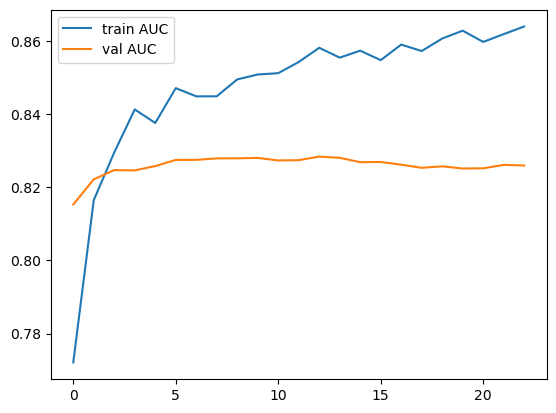

In [17]:
plt.plot(history.history["auc"], label="train AUC")
plt.plot(history.history["val_auc"], label="val AUC")
plt.legend()
plt.show()

O gráfico mostra a AUC de treino subindo até cerca de **0,86**, enquanto a AUC de validação estabiliza perto de **0,825**. Essa distância sugere **leve overfitting**: o modelo continua melhorando nos dados de treino, mas não melhora proporcionalmente na validação. Possíveis ajustes seriam aumentar dropout, simplificar a rede ou parar um pouco antes.


## 18. Teste com threshold 0.4

Neste último bloco vamos testar um threshold menor. Em vez de exigir probabilidade mínima de 0.5 para marcar churn, usamos 0.4. Isso tende a classificar mais clientes como risco, aumentando recall e reduzindo precision.


In [18]:
threshold = 0.4
pred_04 = (proba >= threshold).astype(int)

print(classification_report(y_test, pred_04, digits=3))


              precision    recall  f1-score   support

           0      0.922     0.678     0.782      1035
           1      0.486     0.842     0.616       374

    accuracy                          0.722      1409
   macro avg      0.704     0.760     0.699      1409
weighted avg      0.807     0.722     0.738      1409



Com threshold `0.4`, o recall da classe churn subiu para **0,880**, então o modelo encontrou **88%** dos clientes que cancelaram. Em troca, a precision caiu para **0,474**, indicando mais falsos positivos. Esse corte é interessante se a ação de retenção for barata, como uma campanha automática. Se a ação for cara, o threshold `0.5` pode ser mais equilibrado.


## 19. Comparação de thresholds maiores

Depois de testar o threshold `0.4`, agora vamos avaliar thresholds maiores: `0.5`, `0.55`, `0.6`, `0.65` e `0.7`. A intenção é observar como a precision e o recall da classe churn mudam quando o modelo exige uma probabilidade maior para classificar um cliente como risco.

A lógica esperada é: quanto maior o threshold, menos clientes serão marcados como churn. Isso tende a reduzir falsos positivos e aumentar a precision, mas também costuma reduzir o recall, porque alguns churns reais deixam de ser capturados.


In [19]:
for threshold in [0.5, 0.55, 0.6, 0.65, 0.7]:
    pred_t = (proba >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print(classification_report(y_test, pred_t, digits=3))
    print(confusion_matrix(y_test, pred_t))


Threshold: 0.5
              precision    recall  f1-score   support

           0      0.893     0.758     0.820      1035
           1      0.528     0.749     0.619       374

    accuracy                          0.756      1409
   macro avg      0.711     0.754     0.720      1409
weighted avg      0.796     0.756     0.767      1409

[[785 250]
 [ 94 280]]

Threshold: 0.55
              precision    recall  f1-score   support

           0      0.880     0.786     0.830      1035
           1      0.542     0.703     0.612       374

    accuracy                          0.764      1409
   macro avg      0.711     0.744     0.721      1409
weighted avg      0.790     0.764     0.772      1409

[[813 222]
 [111 263]]

Threshold: 0.6
              precision    recall  f1-score   support

           0      0.867     0.815     0.841      1035
           1      0.562     0.655     0.605       374

    accuracy                          0.773      1409
   macro avg      0.715     0.735

**Análise do resultado**

Os resultados confirmam o trade-off esperado. Com threshold `0.5`, a precision da classe churn ficou em **0,520** e o recall em **0,770**. Ao subir para `0.7`, a precision aumentou para **0,616**, mas o recall caiu para **0,588**.

A matriz de confusão também mostra essa mudança: os falsos positivos caíram de **266** no threshold `0.5` para **137** no threshold `0.7`. Em troca, os falsos negativos subiram de **86** para **154**. Portanto, `0.7` é melhor se o objetivo for abordar menos clientes com maior confiança, mas ele deixa passar mais clientes que realmente cancelaram.


## 20. Busca automática com curva precision-recall

Neste bloco vamos calcular a curva precision-recall para vários pontos de corte possíveis. Em vez de testar apenas alguns thresholds manualmente, essa abordagem cria uma tabela com muitos thresholds e mostra, para cada um, a precision e o recall correspondentes.

Essa tabela ajuda a escolher o corte de acordo com uma regra de negócio. Por exemplo: buscar alta precision quando a ação de retenção é cara, ou buscar alto recall quando a ação é barata e queremos capturar quase todos os clientes em risco.


In [20]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, proba)

results = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1],
})

results.sort_values("precision", ascending=False).head(10)


,threshold,precision,recall
1406,0.949735,1.000000,0.002674
1405,0.944044,1.000000,0.005348
1404,0.938764,1.000000,0.008021
1403,0.935723,1.000000,0.010695
1402,0.935231,1.000000,0.013369
1398,0.929576,0.888889,0.021390
1399,0.929973,0.875000,0.018717
1400,0.930483,0.857143,0.016043
1401,0.932882,0.833333,0.013369
1371,0.907578,0.805556,0.077540


**Análise do resultado**

Ordenar apenas por precision mostra thresholds muito altos, como valores acima de **0,94**, chegando a precision **1,00**. Porém, o recall nesses casos é quase zero. Isso significa que o modelo acerta os poucos clientes que marca como churn, mas marca clientes demais como `não churn` e deixa quase todos os churns reais passarem.

Esse resultado ensina um ponto importante: precision alta sozinha não basta. Precisamos escolher um threshold que melhore a confiança das previsões positivas sem destruir completamente a capacidade de encontrar clientes que cancelam.


## 21. Escolha de threshold com regra de negócio

Agora vamos filtrar a tabela para encontrar thresholds com **precision da classe churn maior ou igual a 0,60** e **recall maior ou igual a 0,50**. Essa regra procura um meio-termo: reduzir falsos positivos, mas ainda capturar pelo menos metade dos clientes que realmente cancelaram.


In [21]:
results[
    (results["precision"] >= 0.60) &
    (results["recall"] >= 0.50)
].sort_values("recall", ascending=False)


,threshold,precision,recall
1020,0.656385,0.600515,0.622995
1021,0.657792,0.602067,0.622995
1022,0.657995,0.603627,0.622995
1023,0.658600,0.605195,0.622995
1024,0.658883,0.604167,0.620321
...,...,...,...
1115,0.724591,0.648464,0.508021
1116,0.725400,0.650685,0.508021
1117,0.725899,0.649485,0.505348
1118,0.726273,0.648276,0.502674


A tabela mostra que existem vários thresholds que satisfazem essa regra. O primeiro resultado aparece perto de **0,679**, com precision de aproximadamente **0,601** e recall de aproximadamente **0,623**.

Comparando com o threshold `0.5`, esse ponto parece mais adequado para uma estratégia mais seletiva: a precision da classe churn aumenta de cerca de **0,52** para **0,60**, reduzindo falsos positivos, mas o recall ainda fica acima de **0,62**. Ou seja, eu passo a abordar menos clientes por engano, sem perder completamente a capacidade de encontrar quem realmente pode cancelar.

Com base nisso, minha conclusão é que não vale depender apenas de uma coluna binária `churn_pred`. Para o CSV final, faz mais sentido manter `churn_prob` e criar faixas de ação, porque a probabilidade permite priorizar clientes com diferentes níveis de risco.

Uma regra inicial que eu vou usar é:

- **Alto risco:** `churn_prob >= 0.68` - ação direta de retenção;
- **Médio risco:** `0.50 <= churn_prob < 0.68` - ação leve ou monitoramento;
- **Baixo risco:** `churn_prob < 0.50` - sem ação imediata.

Assim, eu consigo levar para o Power BI uma recomendação mais prática para o negócio: separar clientes que exigem ação direta daqueles que devem apenas ser acompanhados. Essa abordagem também facilita criar segmentadores, cards de clientes prioritários e indicadores de receita em risco.


In [22]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

model.save("../models/churn_nn.keras")
joblib.dump(pre, "../models/preprocessor.joblib")

['../models/preprocessor.joblib']